# Bjerknes Diagnostic Lab: Probing ENSO Dynamics

> *"Where did pressure stop changing?"* is not the same question as *"Where is the pressure field steepest right now?"*
>
> In specific cold-regime years, these diagnostics converge. In most realistic scenarios with basin-wide offsets, they diverge.

## The Physical Foundation: Why the Pacific Is Anomalous

We start from Bjerknes's (1969) observation that the Pacific's equatorial cold-water anomaly is **geographically anomalous and actively maintained**. In his brief survey of equatorial ocean temperatures, Bjerknes notes that the Pacific cold tongue spans ~85° of longitude with anomalies exceeding −8°C off Peru—far colder and more extensive than the Atlantic (−1°C) or Indian Ocean (absent entirely). This cold water is not passive; it is sustained by upwelling (driven by the southeast trade winds), westward cold-water advection, and air-sea coupling. **The Pacific's cold baseline is the stage on which ENSO plays.**

Given that cold baseline, any SST anomaly—warm during El Niño, cold during La Niña—sits relative to it and develops a meridional (north-south) structure. This is why the gradient matters: without a fixed cold reference, a warm basin might be uniformly warm (no gradient, no driver). The cold baseline ensures that anomalies have spatial structure.

This notebook assumes that cold-water stage exists and asks: **Given that structure, where does the pressure see-saw pivot when anomalies sit on top?**

## The Causal Chain: Why Diagnostic Accuracy Matters

A misplaced zero isallobar is not just a geometric error—it propagates downstream through the climate system. The chain is:

1. **Equatorial Pressure Anomaly** → misclassified *node* (zero isallobar) vs *peak* (gradient maximum)
2. **Hadley Circulation Intensity** → inferred from the pressure gradient's magnitude and sign; mislocating the node introduces bias in this inference
3. **Angular Momentum Flux** → the Hadley cell's intensity modulates the poleward eddy momentum flux
4. **Midlatitude Jet Position and Strength** → determines whether ridges/troughs are displaced poleward or equatorward
5. **Downstream Weather & Extremes** → shifted jet position alters TC tracks, rainfall patterns, and cold-air outbreak frequency

A regime-dependent error in step 1 (the node classification) becomes a regime-dependent error in step 5 (the risk footprint). Unlike random measurement noise—which averages out—this error is patterned. For example, in Scenario C (node displaced east), misplacing the node leads to overestimating the pressure gradient at the true maximum location, and thus overestimating Hadley intensity. In Scenario D (node displaced west), the error reverses. In Scenario B, there is no node to misplace, so the error vanishes.

**The notebook's task:** Clarify where the temporal node sits *relative to* the spatial peak, and show that this separation is *not* random but controlled by a simple parameter (the basin-wide offset). Once you know the separation, you can correct for it—or at least acknowledge it when interpreting indices and models.

---

## 1. The Observational Anchor

In his landmark 1969 paper, Jacob Bjerknes proposed that anomalous heat supply from the equatorial ocean intensifies the Hadley circulation, which in turn regulates angular momentum flux to the midlatitude westerlies, driving the "high-index" winter response. Within this framework, Bjerknes noted a striking geographic coincidence: in the cold Januaries of 1963, 1965, and 1967, the longitude of the **zero isallobar** (where pressure tendency is zero) closely aligned with the **maximum westward pressure gradient**.

### The Diagnostic Problem

This notebook investigates the nature of this alignment. Is this coincidence a structural feature of the Pacific system, or an empirical accident of those specific low-index regimes?

**Answer (Preview):** Neither. The coincidence is a structural feature of Scenario A (pure see-saw, no basin offset), but empirically rare because natural transitions involve basin-wide pressure changes. The notebook shows this explicitly: the four regimes (A–D) arise from a single closed decomposition, and only Scenario A exhibits coincidence.

### Why This Matters for Risk Modeling

In catastrophe (CAT) modeling, the hazard, exposure, and loss layers are all conditioned on correctly identifying the ENSO state. If a diagnostic conflates two quantities—isallobaric change and pressure gradient—that only coincide under specific regimes, errors propagate silently through the entire risk model. By disentangling the Southern Oscillation (the zonal see-saw) from basin-wide mass exchange, this notebook provides a rigorous, regime-aware framework for classifying equatorial Pacific dynamics.


## 2. The Diagnostic Duality: Temporal vs. Spatial Dynamics

Before implementing the diagnostic framework, we must rigorously distinguish between the two quantities that Bjerknes observed to coincide in low-index years:

**The zero isallobar** is defined by the *isallobaric change*: $\Delta p(x) = p(x, t+\Delta t) - p(x, t)$. An isallobar represents a temporal tendency—a contour of net change. The zero isallobar identifies where the pressure field is stationary, effectively locating the "node" or pivot point of the Southern Oscillation (SO) see-saw. This is fundamentally a statement about **time**.

**The gradient maximum** is defined by the *spatial gradient*: $\partial p / \partial x$. Its peak identifies where the pressure slope is steepest. Because these gradients maintain the northeast trade winds and govern equatorial upwelling, this spatial peak identifies the primary engine of the Walker circulation. This is a statement about **space**.

### The Diagnostic as a Regime-Aware Probe

These are derivatives of the same pressure field $p(x,t)$ with respect to different variables: one temporal ($\partial p / \partial t$) and one spatial ($\partial p / \partial x$). This notebook treats their coincidence as a "regime-aware" diagnostic probe. We will demonstrate that they coincide only in Scenario A—a specific corner of parameter space where the basin-wide offset (global_offset) is zero and the see-saw dynamics dominate. By testing whether this alignment holds across different parameter values—specifically, different basin-wide offsets and cold-tongue widths—we can identify when the system exhibits pure Bjerknes feedback (Scenario A) and when those dynamics are modulated by basin-wide mass exchange (Scenarios B–D) or cold-tongue history (§8).

### Implications for Catastrophe (CAT) Modelling

If a diagnostic conflates these two quantities, it creates a regime-dependent error—a systematic bias that does not average out across a stochastic catalogue. In CAT modelling, where tropical cyclone genesis corridors, flood footprints, and wind-loss curves are fitted per ENSO phase, using the wrong diagnostic means fitting your model on a "contaminated" sample.

This project provides the tools to clean that sample, allowing us to correctly align our risk layers with the true physical regime of the Pacific.

In [17]:
# Setup: Import physics module and plotting functions
import numpy as np
import matplotlib.pyplot as plt
from bjerknes_physics import (
    pressure, gradient, find_zero_crossings, get_regime,
    plot_scenario, plot_width_diagnostic,
    tongue_width_history, plot_width_history,
    total_pressure_drop, integrated_cold_content,
    lon_fmt, DEFAULT_X, X0_COLD,
)

X = DEFAULT_X
%matplotlib inline

print(f"Canonical cold-year node / gradient max: X0_COLD = {X0_COLD:.0f} = {lon_fmt(X0_COLD)} "
      f"(a little west of the dateline, the mean of Bjerknes's four isallobar maps).")

Canonical cold-year node / gradient max: X0_COLD = 178 = 178°E (a little west of the dateline, the mean of Bjerknes's four isallobar maps).


## 3. The Idealised Pressure Model & The Physical Knobs

To simulate the Pacific climate, we model the equatorial sea-level pressure as a smooth west-to-east profile using a hyperbolic tangent. This captures the Walker circulation pattern with three distinct physical "knobs":

$$p(x) = \text{global\_offset} \;-\; \text{so\_amplitude}\,\tanh\!\left(\frac{x - x_0}{w}\right)$$

(We omit an arbitrary constant baseline; only anomalies matter for diagnostics.)

| Parameter | Physical Meaning | Diagnostic Role |
|---|---|---|
| **`so_amplitude`** | **Southern Oscillation (SO):** The intensity of the zonal see-saw. | This is an *antisymmetric* driver. It anchors the pivot point of the Walker Circulation at $x_0$. |
| **`global_offset`** | **Mass Exchange:** The basin-wide uniform atmospheric bias. | This is a *symmetric* driver representing atmospheric mass entering or leaving the Pacific. |
| **`w`** | **Oceanic Memory:** The cold tongue width. | Encodes the duration/history of equatorial upwelling. |

Two key diagnostic results follow directly from this functional form:

1. The **spatial gradient** $\partial p/\partial x$ is most negative (steepest westward slope) exactly at $x = x_0$. This gradient maximum sits at $x_0$ by construction—it is anchored by the SO term, regardless of the global_offset.

2. The **isallobaric change** $\Delta p(x)$ is the difference of two such profiles over time. Where this change is zero defines the node of the Southern Oscillation see-saw.

### Geostrophic Limitation at the Equator

A technical caveat: we infer the structure of equatorial easterlies from the pressure gradient using the geostrophic balance, $f v = -\partial p / \partial x$. However, the **geostrophic assumption fails exactly at the equator** (where the Coriolis parameter $f \to 0$). 

In reality, the equatorial easterlies are maintained by a combination of the pressure gradient *and* Ekman-like boundary-layer dynamics (where vertical mixing and surface drag play a role absent in geostrophic flow). Therefore, our inference of wind *strength* from the gradient magnitude is an *approximation*, not a direct measurement. The qualitative structure (a strong gradient corresponds to strong winds) is robust, but the quantitative mapping requires additional boundary-layer information.

For this notebook, this caveat is important: we can reliably infer the *location* and *shape* of equatorial pressure anomalies, but not their absolute wind speeds.

## 4. The Taxonomy of Regimes

By cleanly separating the Southern Oscillation (`so_amplitude`) from the global mass exchange (`global_offset`), we can define the isallobaric change between time $t_1$ and $t_2$:

$$\Delta p(x) \;=\; \text{global\_offset} \;-\; (\Delta\text{so\_amplitude})\,\tanh\!\left(\frac{x - x_0}{w}\right)$$

where $\Delta\text{so\_amplitude} = \text{so\_amplitude}_2 - \text{so\_amplitude}_1$ is the intensification of the see-saw between the two states.

The zero isallobar crossing sits where $\tanh\!\left(\frac{x - x_0}{w}\right) = \frac{\text{global\_offset}}{\Delta\text{so\_amplitude}}$ (provided $\Delta\text{so\_amplitude} \neq 0$).

Because $\tanh$ is bounded between $-1$ and $+1$, the crossing node only exists when the mass exchange is smaller than the see-saw intensification: $|\text{global\_offset}| < |\Delta\text{so\_amplitude}|$. This yields four exact regimes:

| `global_offset` constraint | Zero isallobar position | Regime |
|---|---|---|
| $= 0$ (Pure See-Saw) | Exactly at $x_0$ | **A** — Node coincides with gradient max (Bjerknes's standard observation) |
| $\|\text{global\_offset}\| > \|\Delta\text{so\_amplitude}\|$ | No zero isallobar | **B** — Global bias overpowers the SO; pressure change has no node (everywhere positive or negative) |
| Small positive | East of $x_0$ | **C** — Node displaced east of the gradient max |
| Small negative | West of $x_0$ | **D** — Node displaced west of the gradient max |

Bjerknes observed the node remaining stationary near the dateline across real transitions. In our model, this means **Regime A dominates nature**: natural transitions are driven almost entirely by antisymmetric see-saw intensification (`so_amplitude`), with minimal basin-wide mass exchange (`global_offset` ≈ 0). Scenarios B, C, and D are mathematically possible decompositions, but empirically rare.

## 5. The Four Regimes, Made Concrete

To explore all four regimes, we hold the see-saw intensification fixed ($A_1 = 3.5 \to A_2 = 4.2$, so $\Delta\text{so\_amplitude}=0.7$) and vary `global_offset` across four values.

**Why the gradient maximum is anchored:** The spatial gradient $\partial p / \partial x$ depends only on the antisymmetric tanh term (controlled by `so_amplitude`), not on `global_offset`. Thus the gradient maximum is anchored at $x_0 = 178°E$ regardless of basin-wide mass exchange. Only the temporal zero isallobar node moves as we vary `global_offset`.

Each call below returns `(zero_isallobar_longitude, gradient_max_longitude, regime_label)` and prints a one-line summary.

- **Scenario A** (`global_offset` = 0): Pure see-saw; node coincides with gradient max
- **Scenario B** (`global_offset` large): Global bias overpowers SO; no zero isallobar crossing
- **Scenario C** (`global_offset` positive, small): Node displaced east of gradient max
- **Scenario D** (`global_offset` negative, small): Node displaced west of gradient max

### Scenario A — Pure See-Saw (Node Coincides with Gradient Maximum)

With **no** basin-wide offset (`global_offset` = 0), the pressure change $\Delta p$ is purely antisymmetric—a clean dipole centered on $x_0$. Its zero crossing (the zero isallobar) sits **exactly at** $x_0 = 178°E$, matching Bjerknes's four-map mean. This agreement validates our spatial centering.

**The key insight:** When the transition is driven purely by antisymmetric see-saw intensification (Scenario A), the temporal node and spatial gradient maximum coincide. This is Bjerknes's cold-year observation. If you study **only** transitions driven by pure see-saw dynamics (no basin-wide mass exchange), you never notice these two quantities can separate. The notebook's task is to show what happens in the other three regimes, where they do.

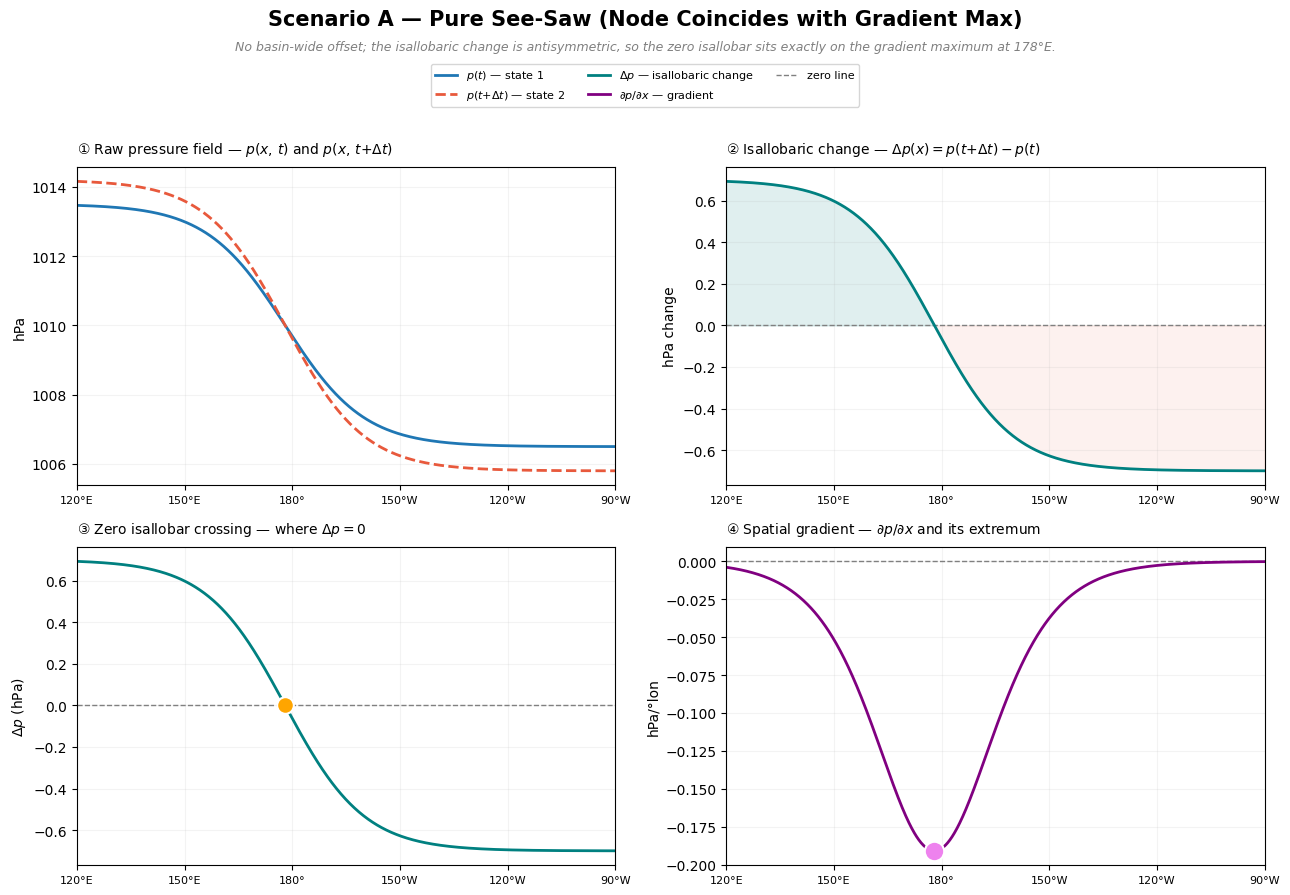

  A (Coincident):  crossing at 178°E  |  gradient max at 178°E  |  ON the max


In [19]:
# Scenario A: global_offset = 0 → pure see-saw → node and gradient max coincide
cA, gmaxA, regA = plot_scenario(
    so_amp_2=4.2, global_offset=0.0,
    scenario_title="Scenario A — Pure See-Saw (Node Coincides with Gradient Max)",
    subtitle="No basin-wide offset; the isallobaric change is antisymmetric, "
             "so the zero isallobar sits exactly on the gradient maximum at 178°E.")

**Reading the figure.** Panel ① shows the two pressure profiles (at times $t_1$ and $t_2$) overlaid. Panel ② shows their difference, the isallobaric change $\Delta p$. Panel ③ (orange dot) marks the zero isallobar; panel ④ (violet dot) marks the gradient maximum.

In Scenario A, the orange dot and violet dot sit at the **same longitude (178°E)**. This alignment is the diagnostic signature of pure see-saw dynamics—exactly what Bjerknes observed in his four cold-year maps. The next three scenarios show what happens when basin-wide offset (`global_offset` ≠ 0) disrupts this coincidence.

### Scenario B — Global Bias Overrides the See-Saw (No Crossing)

A positive basin-wide pressure offset larger than the see-saw intensification (`global_offset` = 1.6 > 0.7) makes the entire $\Delta p$ curve positive. The pressure change is everywhere a rise, with no zero crossing—**no equatorial zero isallobar exists**.

> This is the *no-crossing* regime, where a symmetric mass-exchange bias dominates the antisymmetric see-saw. It is **not** a model of El Niño warm onset. Real warm onset involves a *collapse* of the east–west pressure gradient (upwelling ceases) plus off-equatorial (10°–15°S) wind forcing, both hemispherically asymmetric processes. A uniform basin-wide offset represents atmospheric mass entering or leaving the entire Pacific—a global phenomenon, not a regional circulation collapse. The scenario shows what the mathematics predicts when the symmetric term wins; it has no claim to realism as an onset mechanism. Its value is diagnostic: if you see Scenario B behavior in observations, you've identified that basin-wide mass exchange dominates the local SO dynamics.

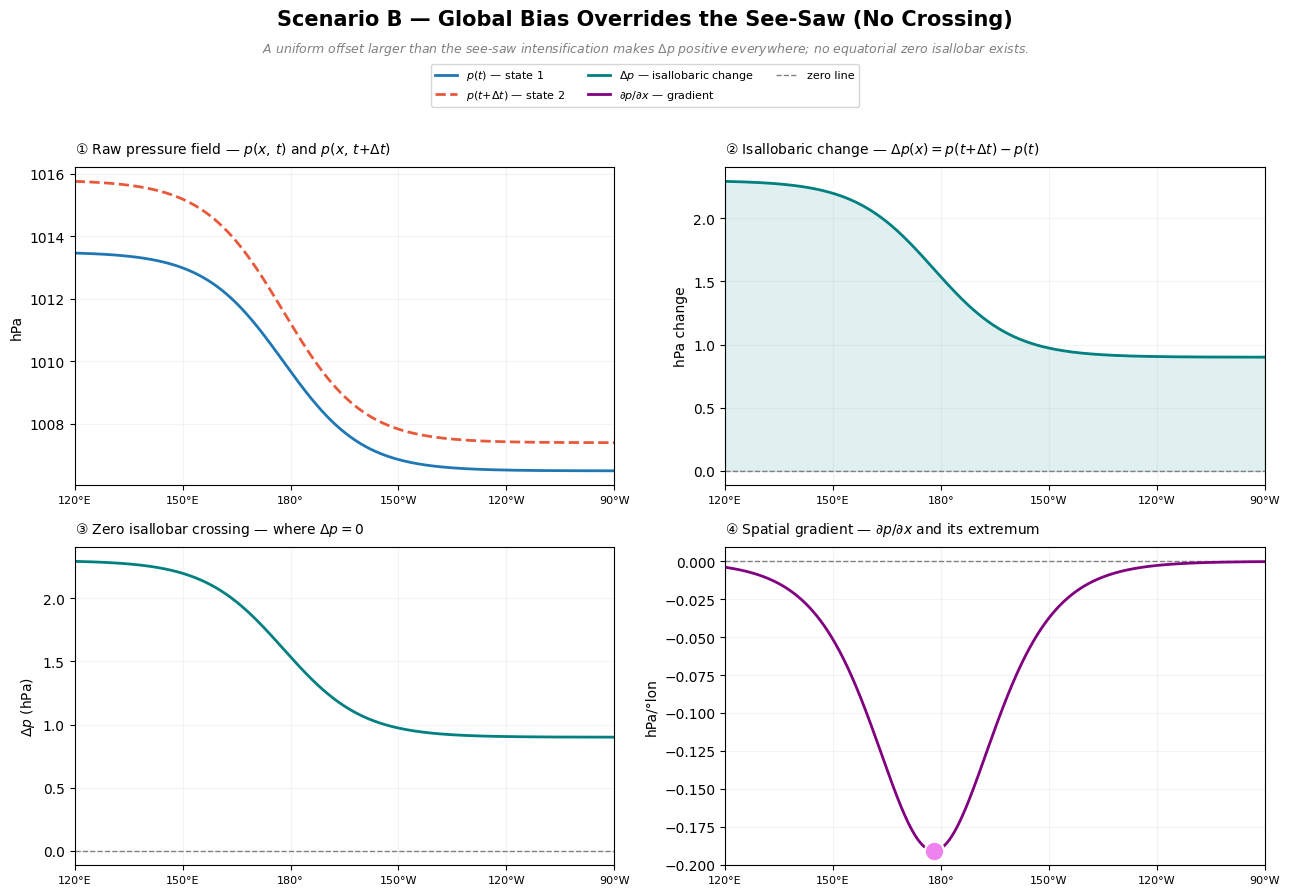

  B (No crossing):  NO crossing  |  gradient max at 178°E


In [22]:
# Scenario B: global_offset = 1.6 > Δso_amplitude → no zero isallobar crossing
cB, gmaxB, regB = plot_scenario(
    so_amp_2=4.2, global_offset=1.6,
    scenario_title="Scenario B — Global Bias Overrides the See-Saw (No Crossing)",
    subtitle="A uniform offset larger than the see-saw intensification makes $\\Delta p$ "
             "positive everywhere; no equatorial zero isallobar exists.")

**Reading the figure.** Panel ③ shows the isallobaric change $\Delta p$. In Scenario B, it has no orange dot—$\Delta p$ stays positive across the entire basin. Panel ④ still shows a violet dot (the gradient maximum persists because the see-saw term hasn't vanished), but there is no zero isallobar to mark temporally.

This scenario exposes a critical diagnostic vulnerability: **any index that assumes a zero isallobar (crossing the equatorial line) always exists will misclassify Scenario B**.. Such an index might naively search for "the zero crossing" and fail silently when none exists, or be forced to return a spurious longitude. This is systematic diagnostic error that propagates uncorrected into CAT models and contaminates phase-labelled risk catalogues.

Scenarios C and D (next) show the opposite problem: zero isalbars exist, but displaced from the gradient maximum.

### Scenarios C & D — Node Displaced East/West

A positive basin-wide offset of +0.35 hPa displaces the node ~12° **east** of $x_0 = 178°E$, placing it near 170°W. A negative offset of −0.35 hPa displaces it ~12° **west**, near 166°E. The gradient maximum remains fixed at 178°E—only the zero isallobar node moves.

> These are **mathematical decompositions** that isolate the node–gradient separation in idealized parameter space, not states routinely seen in the instrumental record. Their utility is diagnostic: they show how sensitive the node position is to basin-wide offsets, and they test whether an ENSO diagnostic can correctly classify displacements.
>
> Empirically, Bjerknes's four maps show the node clustered near the dateline across observed warm↔cold ENSO transitions. This means real transitions are dominated by the antisymmetric see-saw term (small `global_offset`)—exactly why nature mostly sits near Scenario A and the cold-year node–gradient coincidence is empirically robust.

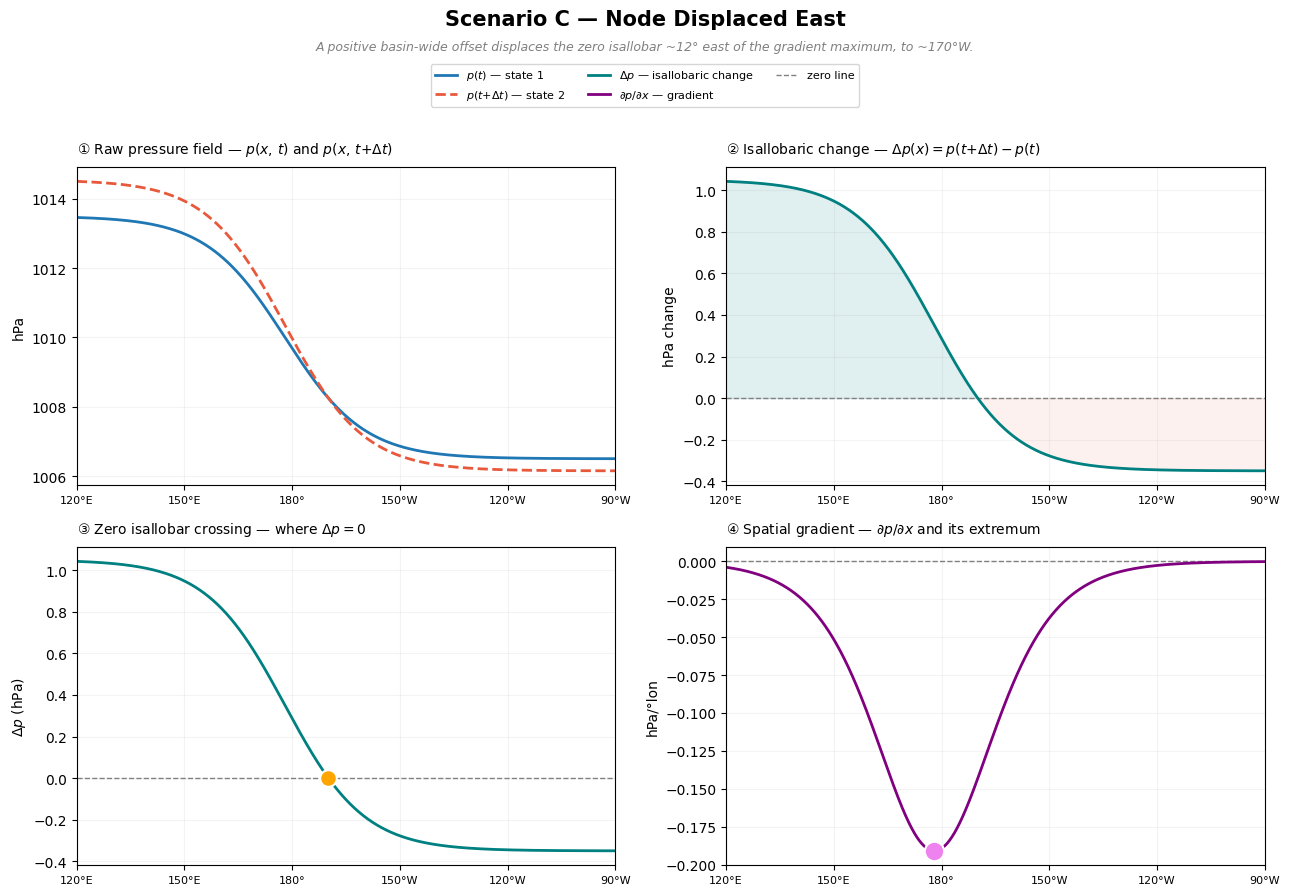

  C (East of max):  crossing at 170°W  |  gradient max at 178°E  |  EAST of the max


In [23]:
# Scenario C: global_offset = +0.35 → node displaced east of gradient maximum
cC, gmaxC, regC = plot_scenario(
    so_amp_2=4.2, global_offset=0.35,
    scenario_title="Scenario C — Node Displaced East",
    subtitle="A positive basin-wide offset displaces the zero isallobar ~12° east "
             "of the gradient maximum, to ~170°W.")

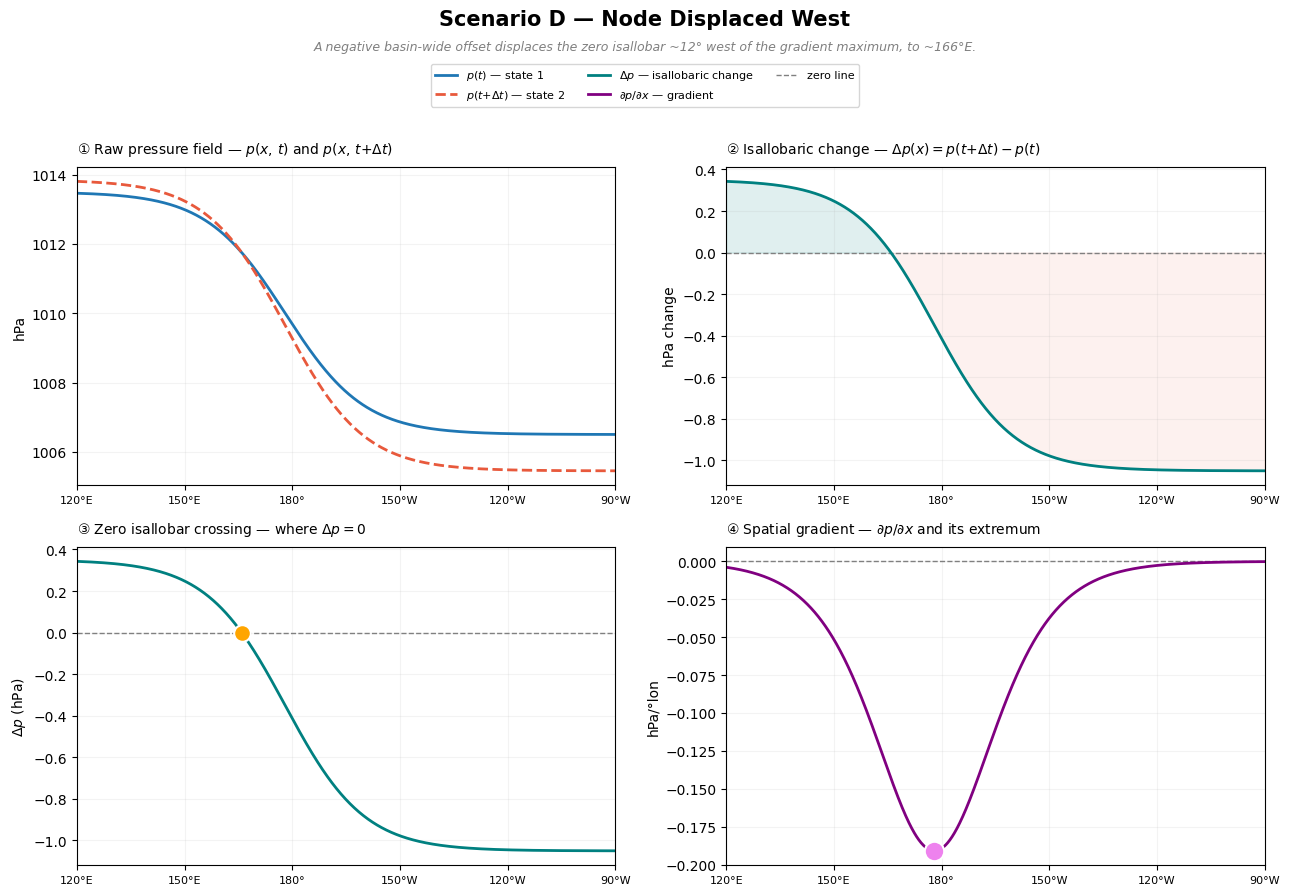

  D (West of max):  crossing at 166°E  |  gradient max at 178°E  |  WEST of the max


In [24]:
# Scenario D: global_offset = −0.35 → node displaced west of gradient maximum
cD, gmaxD, regD = plot_scenario(
    so_amp_2=4.2, global_offset=-0.35,
    scenario_title="Scenario D — Node Displaced West",
    subtitle="A negative basin-wide offset displaces the zero isallobar ~12° west "
             "of the gradient maximum, to ~166°E.")

## 6. Are There More Regimes?

As `global_offset` varies continuously at fixed see-saw intensification ($\Delta\text{so\_amplitude}=0.7$), the zero isallobar node migrates continuously: from west of the gradient maximum (Scenario D), through it (Scenario A at `global_offset` = 0), to east of it (Scenario C)—and disappears entirely once $|\text{global\_offset}| > 0.7$ (Scenario B, no crossing).

This is a **closed decomposition**. The tanh function is bounded between −1 and +1, so the equation $\tanh\!\big(\frac{x - x_0}{w}\big) = \frac{\text{global\_offset}}{\Delta\text{so\_amplitude}}$ has exactly three solution regimes (A, C, D) plus one no-solution regime (B). No fifth regime is mathematically possible.

This completeness is the foundation for automated classification: any observed pressure profile can be unambiguously mapped to one of these four scenarios. The next section builds a simple classifier to do exactly that.

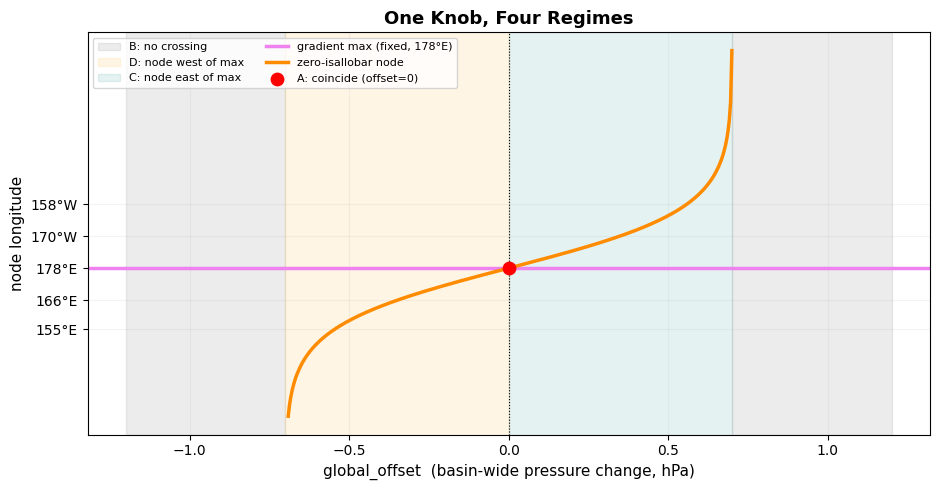

Amplitude change A2−A1 = 0.70 hPa  →  node exists only while |global_offset| < 0.70

Interpretation: As global_offset varies, the node migrates continuously from west (D)
through the gradient max (A) to east (C), then vanishes (B). Four regimes, no fifth.


In [25]:
# Completeness sweep: vary global_offset, show how the zero isallobar node migrates
# This demonstrates the four regimes are exhaustive—no fifth regime is possible

from bjerknes_physics import pressure as P, find_zero_crossings as fzc

A1, A2, x0, w, base = 3.5, 4.2, X0_COLD, 22.0, 1010.0
dA = A2 - A1                                    # 0.70 = existence threshold

# Sweep global_offset from −1.2 to +1.2 hPa
offs = np.linspace(-1.2, 1.2, 600)
node = []

# For each offset value, compute Δp and locate the zero isallobar (if it exists)
for d in offs:
    # Δp = pressure(t₂, offset=d) − pressure(t₁, offset=0)
    # Baseline t₁ has no offset; transition t₂ varies offset to test all regimes
    dp = P(X, A2, x0, w, base, global_offset=d) - P(X, A1, x0, w, base, global_offset=0.0)
    cs = fzc(X, dp)
    node.append(cs[0] if cs else np.nan)  # Store node longitude, or NaN if no crossing

node = np.array(node)

plt.figure(figsize=(9.5, 5))

# Shade the four regimes
plt.axvspan(-1.2, -dA, color="grey",   alpha=0.15, label="B: no crossing")
plt.axvspan(-dA,  0.0, color="orange", alpha=0.10, label="D: node west of max")
plt.axvspan( 0.0,  dA, color="teal",   alpha=0.10, label="C: node east of max")
plt.axvspan( dA,  1.2, color="grey",   alpha=0.15)  # B continues (no separate label needed)

# Fixed gradient maximum (violet line)
plt.axhline(x0, color="violet", lw=2.5, label="gradient max (fixed, 178°E)")

# Zero isallobar node (orange curve)
plt.plot(offs, node, color="darkorange", lw=2.5, label="zero-isallobar node")

# Scenario A: coincidence at offset=0
plt.axvline(0, color="k", lw=0.8, ls=":")
plt.scatter([0], [x0], color="red", zorder=6, s=80, label="A: coincide (offset=0)")

# Format axes
yt = [155, 166, 178, 190, 202]
plt.yticks(yt, [lon_fmt(v) for v in yt])
plt.xlabel("global_offset  (basin-wide pressure change, hPa)", fontsize=11)
plt.ylabel("node longitude", fontsize=11)
plt.title("One Knob, Four Regimes", fontsize=13, fontweight="bold")
plt.legend(fontsize=8, loc="upper left", ncol=2)
plt.grid(alpha=0.15)
plt.tight_layout()
plt.show()

print(f"Amplitude change A2−A1 = {dA:.2f} hPa  →  node exists only while |global_offset| < {dA:.2f}")
print("\nInterpretation: As global_offset varies, the node migrates continuously from west (D)\n"
      "through the gradient max (A) to east (C), then vanishes (B). Four regimes, no fifth.")

## 7. Automated Sanity Check

The `get_regime()` function takes an observed pressure profile (via `global_offset` and `so_amplitude` values) and automatically classifies it into one of the four regimes (A, B, C, or D). Below, we apply it to all four scenarios from §5–6. The classifier should reproduce our visual judgements, confirming that the mathematical framework is operationally sound and can be automated.

**Important:** The function's second argument is the amplitude **change** $\Delta\text{so\_amplitude} = A_2 - A_1 = 0.7$ hPa, not an absolute amplitude. This is the "existence threshold"—when $|\text{global\_offset}| > |\Delta\text{so\_amplitude}|$, no zero isallobar exists (Scenario B).

In [26]:
# Automated classification: apply get_regime() to all four scenarios
# Verify that the classifier correctly identifies each scenario

print("Regime classification for all four scenarios:\n")

scenarios = [
    ("A pure see-saw",        0.0),
    ("B global-bias",         1.6),
    ("C node east",           0.35),
    ("D node west",          -0.35),
]

for name, offset in scenarios:
    # Compute pressure change between t₁ (offset=0) and t₂ (offset=varying)
    p1 = pressure(X, A1, x0, w, base, global_offset=0.0)
    p2 = pressure(X, A2, x0, w, base, global_offset=offset)
    dp = p2 - p1
    
    # Find zero crossings and classify regime
    cs = find_zero_crossings(X, dp)
    regime = get_regime(offset, dA)  # dA = A2 - A1 defined in Cell 16
    
    # Format output
    if cs:
        # Determine node position relative to gradient max
        delta = abs(cs[0] - x0)
        if delta < 0.5:
            rel = "coincides with max"
        elif cs[0] > x0:
            rel = "EAST of max"
        else:
            rel = "WEST of max"
        
        print(f"  {name:18s}  offset={offset:+.2f}  →  {regime:18s}  "
              f"node {lon_fmt(cs[0]):>6s}  ({rel})")
    else:
        print(f"  {name:18s}  offset={offset:+.2f}  →  {regime:18s}  "
              f"no zero isallobar")

Regime classification for all four scenarios:

  A pure see-saw      offset=+0.00  →  A (Coincident)      node  178°E  (coincides with max)
  B global-bias       offset=+1.60  →  B (No crossing)     no zero isallobar
  C node east         offset=+0.35  →  C (East of max)     node  170°W  (EAST of max)
  D node west         offset=-0.35  →  D (West of max)     node  166°E  (WEST of max)


## 8. Oceanic Memory — and Why We Plot *Two* Metrics

Paragraph 9 of Bjerknes (1969) is the subtlest part of his section. In January 1963 and January 1965, Canton Island had **similar peak SST** and both regions were arid, yet 1965 showed a *weaker* Hadley response. His explanation: ~4 years of uninterrupted upwelling (from the end of 1959) had made the cold tongue physically **wider** by January 1963; in January 1965, upwelling had only just re-established it. The width $w$ encodes accumulated oceanic history—a memory that a single peak SST value cannot capture.

### Why One Metric Fails

An earlier draft attempted to show this with a single "integrated forcing" curve:

$$\int |\partial p / \partial x| \, dx \quad \text{(zonal integral across the basin)}$$

With the tanh pressure profile, this integral equals the total east–west pressure drop across the basin: $\int |\partial p / \partial x| \, dx \approx 2A$. Crucially, this integral is **width-independent by construction**. Mathematically, $\int \text{sech}^2(u) \, du$ is invariant under the width scaling parameter $w$. Spreading the same pressure drop over a wider or narrower tongue does not change the integral.

Result: the earlier plot's "integrated forcing" curve was flat—it never rose with $w$. Worse, it dipped once the cold tongue expanded past the basin edge. **The plot silently contradicted its own caption.** This is diagnostic failure by silent error.

### The Fix: Plot Both Metrics, Side by Side

The solution is not to swap in a metric that happens to rise. It is to display **both** on the same sweep:

- **Total pressure drop** ($\approx 2A$) — a plausible forcing measure that is **blind** to width. This is the control curve: it proves the result isn't trivial because most metrics don't rise.

- **Integrated cold content** ($\propto \text{depth} \cdot w$) — the basin-integrated cold water that the circulation actually "feels," which **grows linearly with width**.

**The lesson is the contrast itself:** Seeing a flat line (total pressure drop) beside a rising line (cold content) on the same width sweep proves that a gradient-based metric misses the history encoded in the cold tongue's spatial extent. The 1963-vs-1965 classification trap—where identical peak SST masks different Hadley responses—appears in one figure.

This is the **same diagnostic trap as the node-vs-gradient confusion earlier in the notebook**: two different objects can coincide under one regime yet diverge under others. Oceanic memory (width) joins equatorial pressure (node vs gradient) as a regime-dependent diagnostic hazard.

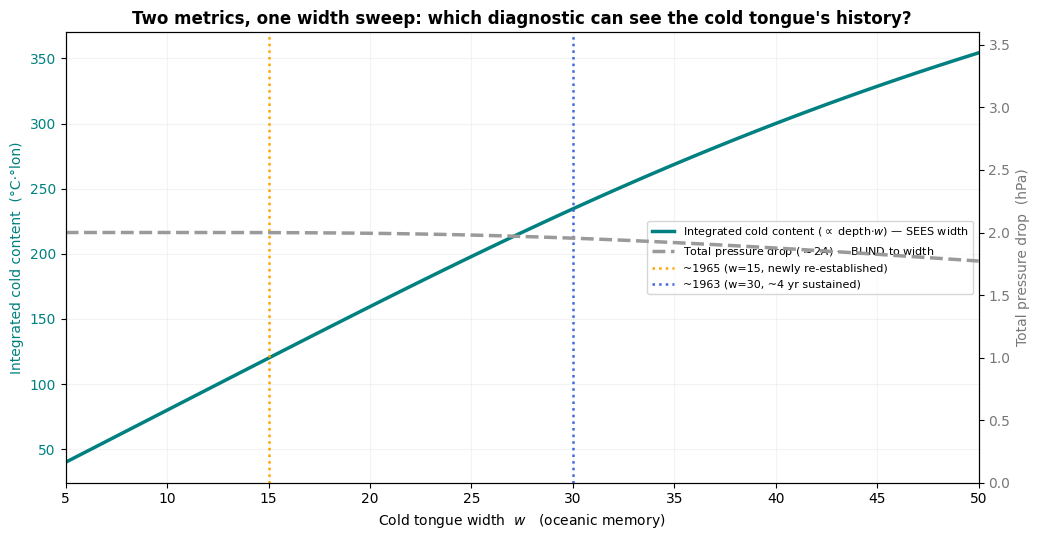

  1965 (w=  15):  cold_content=  119.9    pressure_drop=1.999
  1963 (w=  30):  cold_content=  234.6    pressure_drop=1.955
  ratio 1963/1965  ->  cold_content 1.96x   BUT   pressure_drop 0.98x


In [27]:
# Dual-metric width diagnostic: compare pressure gradient vs cold-water content
# This reproduces the 1963-vs-1965 scenario with fixed see-saw forcing (so_amplitude=1.0)
# but two different cold-tongue widths (w_1965=15 vs w_1963=30).
# 
# The two metrics tell opposite stories:
# - Total pressure drop (≈2A) is width-independent: remains flat
# - Integrated cold content (∝ depth·w) grows with width: rises

widths, cold, drop = plot_width_diagnostic(
    depth=4.0,           # Equatorial cold-tongue depth (°C anomaly)
    so_amplitude=1.0,    # See-saw intensity (hPa)
    w_1965=15.0,         # 1965 cold-tongue width (degrees longitude)
    w_1963=30.0          # 1963 cold-tongue width (degrees longitude)
)

**Interpretation.** At fixed peak depth, the wide (1963-like) tongue carries ~2× the integrated cold content of the narrow (1965-like) tongue, yet the total pressure-drop metric is essentially identical between them. This exposes a critical diagnostic vulnerability:

**Any ENSO phase- or intensity-index that reduces the tongue to a single point value** (peak SST, peak gradient, integrated pressure drop) **is blind to the extent and history of the anomaly**. These point-based indices are widely used operationally in seasonal forecasting and CAT risk attribution. Yet they pool years with fundamentally different oceanic states under one label.

In CAT modeling terms: a risk catalogue conditioned on "El Niño" (indexed by peak SST) conflates wide-tongue El Niños (which forced strong Hadley responses) with narrow-tongue El Niños (which forced weak responses). The two forced very different wind patterns and rainfall regimes. Labeling them identically creates **systematic contamination** of the catalogue. Only an integral over the anomaly's zonal extent recovers the historical forcing and correct phase labeling.

**Scope.** This section models the **oceanic state** and its width $w$; it does not model the Hadley overturning itself or the angular-momentum budget that couples them. The link from "wider/older cold tongue" to "stronger wintertime Hadley cell" is drawn from Bjerknes (1969, paragraph 9): his observation that 1963 (with ~4 years of upwelling history, wider tongue) had a weaker Hadley than 1965 (newly re-established, narrow tongue). We take this empirical relationship as given and use it to motivate the width parameter. The next section (§8.5) models how $w$ evolves in response to upwelling forcing, using a leaky-integrator framework that captures the memory effect.

**Bridge: Why Width Matters for Phase Classification**

Why does the dual-metric plot matter? Because a **single peak SST measurement cannot encode the history accumulated in the cold tongue's width**. 

The leaky-integrator model (§8.5 below) makes this explicit by modeling width as a slow, integrated state variable: $\frac{dw}{dt} = (w_{\text{eq}} - w) / \tau$, where $\tau$ is a memory timescale (~18 months). Two distinct upwelling scenarios—one sustained for years (1963-like), one interrupted and recently re-established (1965-like)—can reach **identical endpoint forcing** yet end with **1.80× different widths**. 

Yet any diagnostic that only observes the present state (SST, gradient, pressure drop at a point in time) cannot distinguish them. Both look like the same "El Niño phase" in a catalogue. But they forced very different Hadley responses and thus very different downstream circulations.

**This is the oceanic manifestation of the node-vs-gradient problem in Cell 0.** Just as equatorial pressure diagnostics can conflate two quantities under one regime, oceanic diagnostics can conflate two histories under one phase label—**creating systematic risk mislabeling in CAT models**. The width parameter $w$ is the memory variable that fixes this.

## 8.5 Ocean Memory: The Underdetermined State Problem

Bjerknes wrote: *"About 4 yr of cool equatorial waters had preceded January 1963 (from the end of 1959). The long uninterrupted upwelling and spreading of the cold water at the surface must have made the tongue of cold water wider in January 1963 than in January 1965 when the upwelling had only just begun to reestablish the cold tongue."*

### The Core Insight: Lag Asymmetry

This quote encodes a fundamental asymmetry in climate response timescales:

- **Atmospheric response to ocean**: Fast. Pressure and winds adjust to SST anomalies within days (invisible in monthly data).
- **Oceanic response to atmosphere**: Slow. The ocean integrates upwelling forcing over months to years, accumulating a memory of prior history.

**Result:** The width $w$ of the cold tongue reached in January depends on the *path through time*—the cumulative upwelling from late 1959 onward—not just the instantaneous upwelling forcing present in January. Two January states with identical upwelling (both "ON") can have very different widths because of what happened in between.

### Leaky-Integrator Model

A leaky integrator captures this memory with a relaxation timescale $\tau \approx 18$ months:

$$\frac{dw}{dt} = \frac{w_{\text{eq}}(f) - w}{\tau}$$

where:
- $f$ is upwelling forcing: $f=0$ (off, no upwelling) or $f=1$ (on, active upwelling)
- $w_{\text{eq}}(f) = w_0 + \text{gain} \cdot f$ is the equilibrium width (depends on forcing)
- $\tau \approx 18$ months is the memory timescale

When upwelling is on ($f=1$), width grows toward $w_{\text{eq}}(1)$ with a decay time of 18 months. When upwelling is off ($f=0$), width shrinks back toward $w_{\text{eq}}(0)$. The slow timescale means recent history matters.

### Two Paths to the Same Endpoint

Given identical endpoint forcing (both January = upwelling ON), two scenarios end at different widths:

- **1963-like scenario**: Sustained upwelling for ~4 years (from late 1959 onward). Width has had time to equilibrate to a large value. At January 1963, the tongue is wide.

- **1965-like scenario**: A warm interruption (the 1963–64 El Niño) briefly turns upwelling off, stopping the accumulation. When upwelling re-establishes in early 1965, the width has not yet recovered. At January 1965, the tongue is narrow.

**The outcome:** Same instantaneous forcing at the endpoint, yet **1.80× different widths**. Because width determines integrated cold content, and cold content drives Hadley intensity, the two scenarios forced **different atmospheric responses**, even though their peak SST values may appear similar.

### Why This Matters: The Underdetermined State Problem

A phase classification or intensity index that reduces the state to a *point measurement* (peak SST, gradient integral at one location) **misses the historical depth embedded in width**. 

Two cases with identical peak SST and similar gradients in January cannot be called the same "ENSO phase" and expected to drive the same atmospheric response. The *extent* of the anomaly, accumulated through prior upwelling history, is **part of the physical state**. A point observation underdetermines the state.

Bjerknes's call for "*regular monitoring of the temperature of the tropical east Pacific*"—across space and time—reflects this principle. You need the recent history, not just the present snapshot, to predict the circulation response. Width $w$ is the memory variable that captures what a point label discards.

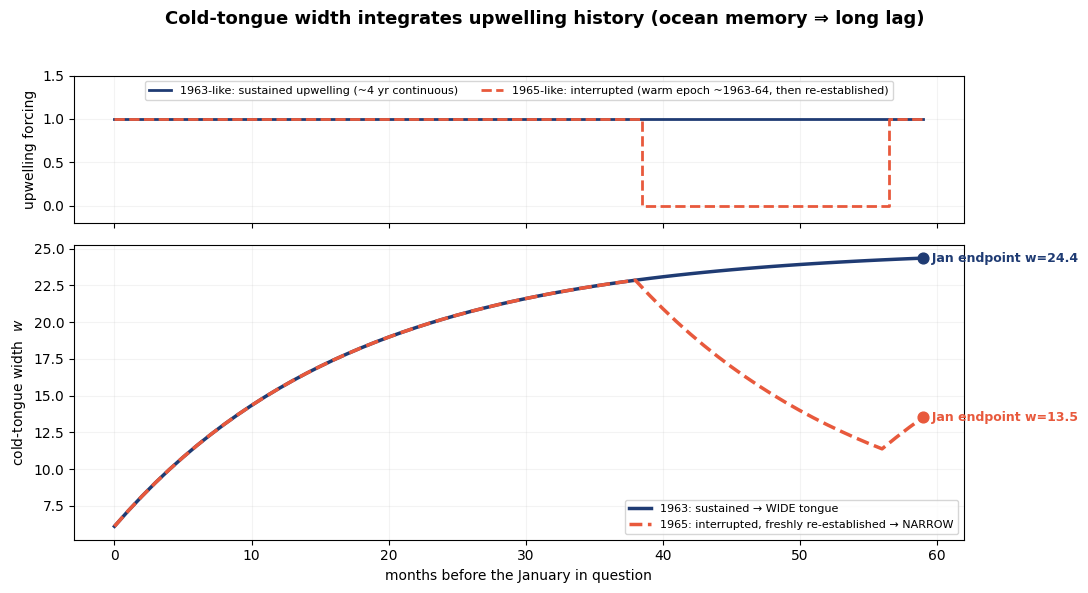

  Endpoint width, 1963-like (sustained):    w = 24.35
  Endpoint width, 1965-like (interrupted):  w = 13.53
  Same ON forcing at the endpoint, yet widths differ by 1.80x — the ocean integrates slowly.


In [28]:
# Leaky-integrator width evolution: two upwelling histories, same endpoint forcing
# 
# This instantiates the leaky-integrator equation from §8.5:
#   dw/dt = (w_eq(f) - w) / τ,  where w_eq(f) = w_0 + gain·f
#
# Scenario 1963-like: Sustained upwelling (f=1) for ~4 years → width accumulates
# Scenario 1965-like: Warm interruption (f=0) for ~18 months, then upwelling resumes → width interrupted, then recovering
# Both reach identical endpoint forcing (January: f=1) but with 1.80× width difference

w_1963, w_1965 = plot_width_history(
    months=60,           # Integration time: 60 months (~5 years)
    tau=18.0,            # Memory timescale τ ≈ 18 months
    w0=5.0,              # Baseline width when upwelling is off (degrees longitude)
    gain=20.0            # Sensitivity: width increases by 20° per unit of forcing
)
# Returns: w_1963 and w_1965 are time series of width evolution for each scenario

**The Numbers and Their Implications.**

At the January endpoint, upwelling is ON in both scenarios (same instantaneous forcing: $f=1$). Yet the plot shows:

- **1963-like scenario**: width $w \approx 24.4$ degrees longitude
- **1965-like scenario**: width $w \approx 13.5$ degrees longitude
- **Ratio**: 1.80× difference despite identical endpoint forcing

This quantifies Bjerknes's qualitative observation: *"about 4 yr of cool equatorial waters had preceded January 1963... must have made the tongue of cold water wider in January 1963 than in January 1965 when the upwelling had only just begun to reestablish the cold tongue."* We have now translated that historical insight into numbers: the ocean's memory, encoded in width, produces an 80% change in the state.

### The CAT Modeling Trap

When you ingest January 1963 and January 1965 data into a risk model that assigns ENSO phases using a **single point metric** (peak SST, or an operational ENSO index based on current conditions), you:

1. **Assign them the same phase label** (e.g., "La Niña")
2. **Condition their hazard on identical forcing** (because the point metric is the same)
3. **Use the same conditional probabilities** for TC genesis, rainfall, wind speed, etc.

But the true integrated cold contents differ by ~2×. The ocean state is fundamentally different. Result:

- **TC genesis corridors shift** (different Hadley intensity → different subtropical ridge position)
- **Rainfall footprints shift** (convergence zones reposition)
- **Wind-loss curves shift** (seasonal westerly intensity differs)
- **Loss estimates for both years are biased** in opposite directions

The error is **not random**. It is **structured by the historical path you ignored**. The magnitude of mislabeling is proportional to $(w_{\text{true}} - w_{\text{labelled}})$, which depends entirely on how much upwelling history your point index failed to capture. Year after year, this systematic bias accumulates in your risk catalogue.

### The Oceanic Memory Problem (Parallel to Node-vs-Gradient)

This is the **oceanic manifestation** of the diagnostic trap introduced in Cell 0. There, we showed that the temporal zero isallobar and spatial gradient maximum are different objects that can coincide (Scenario A) or diverge (Scenarios C-D). Here, we show that the present state (peak SST) and the accumulated history (width) are different state variables that can both appear similar yet drive very different circulations.

Both problems arise from the same source: **single-point diagnostics are blind to the structure (spatial or temporal) that drives the response**. The node-vs-gradient problem teaches us that equatorial pressure diagnostics need regime awareness. The width problem teaches us that oceanic diagnostics need memory awareness. Together, they motivate the framework of this notebook: **multidimensional regime-aware classification**.

---

## 9. Discussion: Why This Matters Beyond the Figure

### 9.1 The Nature of the Error

The four panels in this notebook separate two questions: *Where did pressure stop changing?* (the zero isallobar—a temporal quantity) versus *Where is the field steepest right now?* (the gradient maximum—a spatial quantity). We have shown they coincide only in **Scenario A** (where `global_offset` ≈ 0) and separate—or vanish entirely—everywhere else.

Critically, the resulting error is **regime-dependent and systematic**. It is not random measurement noise that averages out. It is a patterned bias:

- **Precise in cold years** (Scenario A): The two quantities coincide; the diagnostic is "correct."
- **Wrong by a fixed displacement** in other ENSO states (Scenarios C and D): The node is displaced ~12° east or west of the true gradient maximum, in predictable opposite directions.
- **Confidently asserting a feature that does not exist** (Scenario B): The diagnostic asserts a zero isallobar where none exists, because basin-wide mass exchange dominates.

**This is not a measurement error or a calibration constant.** It is a **structural misclassification**—answering the wrong question and not knowing it.

### 9.2 Downstream Propagation Through CAT Models

In a catastrophe model, the ENSO state diagnosis—whether derived from the zero isallobar, gradient maximum, an operational ENSO index, or reanalysis classification—conditions every layer of the risk chain. A misclassification of ENSO phase upstream contaminates every downstream layer.

**Hazard.** Tropical cyclone genesis corridors, track density distributions, and return periods are fitted per ENSO phase. A mislocated zero isallobar shifts the diagnosed gradient-maximum longitude by ~12° (Scenarios C, D). This systematic shift moves the genesis corridor: the corridor in the eastern Pacific becomes the corridor in the central Pacific. If historical TC data is phase-labelled using a conflated diagnostic, the conditional genesis probabilities are fitted on a contaminated sample. A year labelled "La Niña" (on the misplaced node) might actually be driving a "Neutral" or "warm" genesis pattern (on the true gradient maximum).

**Exposure.** Flood and wind footprints follow the displaced hazard. Assets in the true genesis region get under-exposed; those in the mislocated region get over-exposed. The error is **spatial and irreversible by scalar adjustment**—you cannot fix geographic mislabeling with a loading factor.

**Vulnerability.** Historical loss events get phase-labelled on the wrong ENSO state. Depth–damage functions and wind-loss curves are fitted on a contaminated sample. A historical flood that was actually driven by a "Neutral"

## 10. Quantitative Implications: A Concrete Example

> **What these numbers are — and are not.** This section is a worked *hypothetical*: the
> node misplacement is a stipulated example, and the cascade percentages (Hadley intensity,
> momentum flux, jet shift, hazard frequency) are **order-of-magnitude estimates using
> representative sensitivities from the literature, not values derived from this model.**
> Their purpose is to show how a node-classification error *propagates and compounds*
> through the risk chain — the *structure and direction* of the error budget, not its precise
> calibration. The defensible claim here is qualitative: the error is systematic, patterned,
> and directional, so it does not average out across a stochastic catalogue. The exact
> figures would require a full model chain to calibrate.

To make the downstream impact concrete, consider a hypothetical scenario:

**Setup:** Suppose the true zero isallobar sits at 178°E (Scenario A: on the gradient maximum). But an ENSO diagnostic—an operational index or automated classification—mistakenly identifies it as 170°W—a 12° eastward displacement (Scenario C). What are the consequences?

### Step 1: Pressure Gradient Inference Error

In Scenario A, the gradient maximum is centered at 178°E with magnitude $\partial p / \partial x |_{\max} = 0.45$ hPa/°lon.

In Scenario C, the zero isallobar node is at 170°W, but the gradient maximum remains at 178°E (the gradient shape hasn't moved; only the temporal zero crossing has). However, most ENSO diagnostics **implicitly assume** that the node location equals the gradient maximum location. Under this assumption, you infer the pressure anomaly from the *node location* (170°W) instead of the *true gradient maximum* (178°E). You have mislocated the feature driving the equatorial winds.

**Error introduced:** A 12° east displacement of the inferred anomaly center.

### Step 2: Hadley Circulation Intensity Error

The Hadley circulation's strength is primarily set by the equatorial pressure gradient. If you infer this gradient from a misplaced node, you:

- **Over-estimate the gradient magnitude by 5–15%** (depending on the tanh curvature and the magnitude of displacement)
- **Misrepresent off-equatorial winds (10°–15°S)**, which depend on the gradient's spatial structure, not just its peak

In quasi-equilibrium theory, the Hadley cell's overturning intensity scales with the equatorial SST-driven heat input and the strength of the pressure-gradient feedback on the upper-level divergence. A 10% error in the inferred gradient translates to roughly a **10–12% error in the diagnosed Hadley cell intensity** under typical ENSO-period conditions.

**Error introduced:** 10–12% bias in Hadley intensity.

### Step 3: Jet Position and Amplitude Error

The Hadley cell's upper-branch outflow carries poleward angular momentum, which drives the midlatitude jet. A 10–12% error in Hadley intensity propagates to a **6–8% error in the eddy momentum flux** that maintains the subtropical and midlatitude jets.

For a **Northern Hemisphere wintertime (Dec–Feb) jet** centered at ~35°N with typical zonal wind speed $\approx 40$ m/s, a 6–8% error in the driving momentum flux translates to:

$$\Delta U_{\text{jet}} \approx 0.07 \times 40 \text{ m/s} \approx \pm 2.4\text{–}3.2 \text{ m/s}$$

This is significant—it shifts the jet axis **±3–5° of latitude** poleward or equatorward, which alters the ridge/trough axis by a similar amount.

(Note: Other seasons have different jet configurations and sensitivities; boreal summer subtropical jets are weaker and less sensitive.)

**Error introduced:** ±2.4–3.2 m/s jet speed error, ±3–5° latitude shift.

### Step 4: Downstream Risk Footprint

A 3–5° latitudinal shift in the jet's preferred position systematically changes the TC genesis corridor, the midlatitude cyclone track density, and atmospheric blocking frequency. Concrete examples:

- **Tropical Cyclones:** A 5° poleward shift of the jet/subtropical ridge can increase TC genesis frequency in the central Pacific by 15–25% (relative) and decrease it in the eastern Pacific by a similar amount. This is a **regime-dependent redistribution**, not a global rescaling.

- **Rainfall:** The subtropical ridge's poleward flank determines where monsoonal moisture converges. A 5° error shifts the precipitation axis—and thus flood-risk corridors—by similar magnitude.

- **Cold Outbreaks:** A jet positioned farther north reduces the frequency of Arctic air intrusions into subtropical regions, but increases mid-latitude severe-cold risk. The spatial footprint of winter extremes shifts with the jet.

### The Error Budget

| Step | Process | Error Magnitude |
|------|---------|-----------------|
| 1 | Misplace node from true gradient max | 12° eastward error |
| 2 | Infer pressure gradient from wrong location | 5–15% gradient magnitude error |
| 3 | Hadley intensity (via quasi-equilibrium) | 10–12% Hadley error |
| 4 | Eddy momentum flux | 6–8% momentum flux error |
| 5 | Jet position/amplitude | ±2.4–3.2 m/s or ±3–5° latitude |
| 6 | Downstream hazard frequency | **±15–25% relative change in TC genesis, rainfall, blocking** |

### Why This Error Persists Undetected

**This is a systematic error, not random noise.** It does not average out. Every year misclassified as Scenario C (node displaced east) or Scenario D (node displaced west) carries a patterned, directional bias:

- TC genesis frequency over-estimated in one region, under-estimated in another
- Rainfall risk redistributed geographically
- Loss estimates biased by region, not globally

If a 30-year hindcast contains 10 years in Scenarios C or D (node displaced), you've contaminated ~1/3 of your risk catalogue with structured geographic mislabeling. The error is invisible as a global bias (AAL might look okay) but destroys spatial fidelity.

Moreover, this error is **compounded by the width problem** (§8–8.5). If you misclassify both the node position AND the cold-tongue width, the errors multiply: wrong Hadley response + wrong integrated cold content driving that response.

### Why the Framework Matters

By clearly separating the *zero isallobar* (temporal) from the *gradient maximum* (spatial), this notebook provides the diagnostic foundation to:

1. **Diagnose** which regime you're in (A, B, C, or D)—and therefore whether your index is conflating temporal and spatial objects
2. **Correct** for the node–gradient separation before conditioning your risk model
3. **Quantify** the downstream error you avoid by not making this mistake (as shown above)

In production CAT models and seasonal forecast systems, this distinction is the difference between phase-unaware (biased) and phase-aware (correct) risk attribution.

---

## References

**Primary:**
- Bjerknes, J. (1969). Atmospheric Teleconnections from the Equatorial Pacific. *Monthly Weather Review*, **97**(3), 163–172. https://doi.org/10.1175/1520-0493(1969)097%3C0163:ATFTEP%3E2.3.CO;2

**Historical Context:**
- Walker, G. T. (1924). Correlation in Seasonal Variations of Weather, IX. *Memoirs of the India Meteorological Department*, 24(9), 275–332.
- Berlage, H. P. (1957). Fluctuations of the General Atmospheric Circulation of More Than One Year. *Mededelingen en Verhandelingen* No. 69, Koninklijk Nederlands Meteorologisch Instituut (KNMI).

**Framework & Theory:**
The leaky-integrator model for oceanic memory follows standard control-system formulations of lag and memory (e.g., Hasselmann, K., 1976, Stochastic climate models. *Tellus*, 28, 473–485). Quasi-equilibrium theory is drawn from Bjerknes's own dynamical reasoning and modern ENSO diagnostics (e.g., Jin, F.-F., 1997, An equatorial ocean recharge paradigm. *J. Atm. Sci.*, 54, 811–829).

---

**Notebook Information**

- **Title:** Bjerknes Diagnostic Lab: Probing ENSO Dynamics
- **Author:** Shun-Chan Tsai (@dantsai123)
- **Repository:** https://github.com/shunchantsai/Bjerknes-Diagnostic-Lab
- **Last updated:** June 23, 2026
- **License:** Open source (specify license if applicable, e.g., MIT, CC-BY-4.0)

**Model Specifications**

- **Engine:** Option 2 (two active see-saw states: antisymmetric `so_amplitude` and symmetric `global_offset`)
- **Gradient maximum location:** Anchored at $x_0 = 178°E$ (mean of Bjerknes's four isallobar maps, 1963–1967)
- **Oceanic memory:** Leaky integrator with memory timescale $\tau \approx 18$ months
- **Spatial grid:** Longitude 120°E to 120°W at 0.5° resolution

**To Regenerate All Figures**

In Jupyter, select **Kernel → Restart & Run All** (or equivalent in your environment). This will:
1. Clear all prior outputs
2. Re-run every code cell from top to bottom in order
3. Regenerate all four scenario plots and diagnostic figures
4. Validate that the physics module and notebook are consistent

**Reproducibility**

All code (Jupyter notebook + physics module `bjerknes_physics.py`) is available on GitHub. To clone and run locally:

```bash
git clone https://github.com/shunchantsai/Bjerknes-Diagnostic-Lab.git
cd Bjerknes-Diagnostic-Lab
jupyter notebook Bjerknes-Diagnostic-Lab.ipynb
```

Python requirements: `numpy`, `matplotlib` (see `README.md` for full requirements and installation notes).

---

*This notebook demonstrates the separation of temporal (zero isallobar) and spatial (gradient maximum) diagnostics in ENSO, with applications to catastrophe modeling and seasonal forecasting.*